In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

coco_path = '/content/drive/MyDrive/COCO_Dataset'
os.makedirs(coco_path, exist_ok=True)
%cd {coco_path}

!wget http://images.cocodataset.org/zips/val2017.zip
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip


!unzip -q val2017.zip
!unzip -q annotations_trainval2017.zip

print(f"Dataset permanently saved to your Google Drive at: {coco_path}")

Mounted at /content/drive
/content/drive/MyDrive/COCO_Dataset
--2026-03-17 14:13:26--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.183.252, 3.5.7.174, 16.15.207.19, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.183.252|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 777.80M  39.7MB/s    in 21s     

2026-03-17 14:13:48 (36.6 MB/s) - ‘val2017.zip’ saved [815585330/815585330]

--2026-03-17 14:13:48--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.206.153, 16.15.199.8, 16.182.107.153, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.206.153|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Sa

In [ ]:
!pip install ultralytics pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.6 MB/s eta 0:00:00


In [ ]:
import os
import json
from ultralytics import YOLO
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from tqdm.notebook import tqdm

img_dir = '/content/drive/MyDrive/COCO_Dataset/val2017'
ann_file = '/content/drive/MyDrive/COCO_Dataset/annotations/instances_val2017.json'
out_file = 'yolov8_coco_predictions.json'

print("1. Loading Pre-trained YOLOv8 Model...")

model = YOLO('yolov8n.pt')

print("2. Loading COCO Ground Truth...")
coco_gt = COCO(ann_file)
image_ids = coco_gt.getImgIds()


yolo_to_coco = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 70, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 84, 85, 86, 87, 88, 89, 90]

predictions = []

print("3. Running Inference on 5,000 Validation Images...")
for img_id in tqdm(image_ids, desc="YOLOv8 Inference"):
    img_info = coco_gt.loadImgs(img_id)[0]
    img_path = os.path.join(img_dir, img_info['file_name'])


    results = model.predict(img_path, verbose=False)[0]

    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        w = x2 - x1
        h = y2 - y1

        score = float(box.conf[0])
        cls_idx = int(box.cls[0])
        coco_cat_id = yolo_to_coco[cls_idx]

        predictions.append({
            "image_id": img_id,
            "category_id": coco_cat_id,
            "bbox": [round(x1, 3), round(y1, 3), round(w, 3), round(h, 3)],
            "score": round(score, 5)
        })

with open(out_file, "w") as f:
    json.dump(predictions, f)
print(f"\n✅ Saved {len(predictions)} predictions to {out_file}")

print("\n4. Calculating COCO mAP...")

coco_dt = coco_gt.loadRes(out_file)
coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')


coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
1. Loading Pre-trained YOLOv8 Model...
2. Loading COCO Ground Truth...
loading annotations into memory...
Done (t=0.58s)
creating index...
index created!
3. Running Inference on 5,000 Validation Images...


YOLOv8 Inference:   0%|          | 0/5000 [00:00<?, ?it/s]


✅ Saved 26514 predictions to yolov8_coco_predictions.json

4. Calculating COCO mAP...
Loading and preparing results...
DONE (t=0.34s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=11.40s).
Accumulating evaluation results...
DONE (t=1.60s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.313
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.422
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.345
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.113
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.343
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.480
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.260
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.362
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | ma

In [ ]:
!pip install tidecv

1. Loading TIDE Toolbox...
2. Loading Ground Truth and Predictions...
3. Evaluating Errors...
4. Generating Summary and Plots...
-- yolov8_coco_predictions --

bbox AP @ 50: 42.24

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     3.61     4.28     0.44     0.24     1.01    33.56  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP       4.51      45.17  



/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['main'], x='Delta mAP', y='Error Type', ax=ax,
/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['special'], x='Error Type', y='Delta mAP', ax=ax,
/usr/local/lib/python3.12/dist-packages/tidecv/plotting.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['FP', 'FN'])


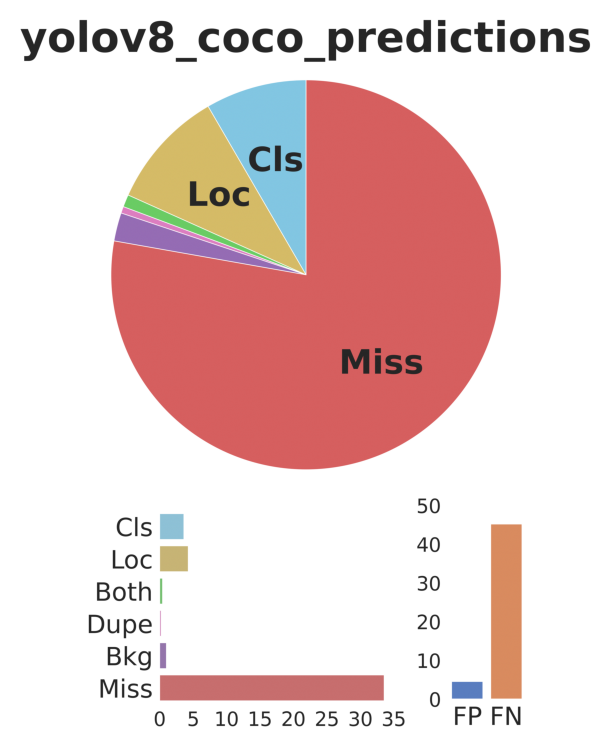

In [ ]:
from tidecv import TIDE, datasets

print("1. Loading TIDE Toolbox...")
tide = TIDE()

print("2. Loading Ground Truth and Predictions...")
gt = datasets.COCO(ann_file)
bbox_results = datasets.COCOResult(out_file)

print("3. Evaluating Errors...")

tide.evaluate(gt, bbox_results, mode=TIDE.BOX)

print("4. Generating Summary and Plots...")
tide.summarize()
tide.plot()

In [ ]:
import numpy as np

print("1. Extracting TP/FP matches directly from COCO Eval...")
scores = []
accuracies = []


iou_idx = 0


for eval_img in coco_eval.evalImgs:
    if eval_img is not None:
        dtScores = eval_img['dtScores']

       
        dtMatches = eval_img['dtMatches'][iou_idx]

        for i in range(len(dtScores)):
            scores.append(dtScores[i])

            is_tp = 1 if dtMatches[i] > 0 else 0
            accuracies.append(is_tp)

scores = np.array(scores)
accuracies = np.array(accuracies)

print("2. Calculating Expected Calibration Error (ECE) across 10 bins...")
num_bins = 10
bins = np.linspace(0.0, 1.0, num_bins + 1)

ece = 0.0
total_predictions = len(scores)

for i in range(num_bins):
    bin_lower = bins[i]
    bin_upper = bins[i+1]

    if i == num_bins - 1:
        in_bin = (scores >= bin_lower) & (scores <= bin_upper)
    else:
        in_bin = (scores >= bin_lower) & (scores < bin_upper)

    bin_scores = scores[in_bin]
    bin_accuracies = accuracies[in_bin]
    bin_count = len(bin_scores)

    if bin_count > 0:
        bin_conf = np.mean(bin_scores)
        bin_acc = np.mean(bin_accuracies)
        bin_weight = bin_count / total_predictions


        bin_error = np.abs(bin_acc - bin_conf)
        ece += bin_weight * bin_error

print(f"\n✅ Total Predictions Evaluated: {total_predictions}")
print(f"✅ Expected Calibration Error (ECE): {ece:.4f}")

1. Extracting TP/FP matches directly from COCO Eval...
2. Calculating Expected Calibration Error (ECE) across 10 bins...

✅ Total Predictions Evaluated: 106056
✅ Expected Calibration Error (ECE): 0.1479


In [ ]:
import json
import numpy as np
from tidecv import TIDE, datasets
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

print("1. Filtering Predictions by Scale...")
with open('yolov8_coco_predictions.json', 'r') as f:
    preds = json.load(f)

scales = {'small': [], 'medium': [], 'large': []}

for p in preds:
    w, h = p['bbox'][2], p['bbox'][3]
    area = w * h
    if area < (36 * 36):
        scales['small'].append(p)
    elif area < (96 * 96):
        scales['medium'].append(p)
    else:
        scales['large'].append(p)

ann_file = '/content/drive/MyDrive/COCO_Dataset/annotations/instances_val2017.json'
coco_gt = COCO(ann_file)

for scale_name, scale_preds in scales.items():
    print(f"\n{'='*60}")
    print(f"🚀 EVALUATING SCALE: {scale_name.upper()}")
    print(f"{'='*60}")

    out_file = f'preds_{scale_name}.json'
    with open(out_file, 'w') as f:
        json.dump(scale_preds, f)

    print(f"✅ Saved {len(scale_preds)} {scale_name} predictions to {out_file}")


    print(f"\n--- TIDE Statistics for {scale_name.upper()} ---")
    tide = TIDE()
    gt_tide = datasets.COCO(ann_file)
    bbox_results = datasets.COCOResult(out_file)
    tide.evaluate(gt_tide, bbox_results, mode=TIDE.BOX)
    tide.summarize()


    print(f"\n--- ECE Calculation for {scale_name.upper()} ---")
    coco_dt = coco_gt.loadRes(out_file)
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')

    coco_eval.params.areaRng = [[0, 1e10]]
    coco_eval.params.areaRngLbl = ['all']

    coco_eval.evaluate()
    coco_eval.accumulate()

    scores, accuracies = [], []
    for eval_img in coco_eval.evalImgs:
        if eval_img is not None:
            dtScores = eval_img['dtScores']
            dtMatches = eval_img['dtMatches'][0]

            for i in range(len(dtScores)):
                scores.append(dtScores[i])
                accuracies.append(1 if dtMatches[i] > 0 else 0)

    scores, accuracies = np.array(scores), np.array(accuracies)

    num_bins = 10
    bins = np.linspace(0.0, 1.0, num_bins + 1)
    ece = 0.0
    total_predictions = len(scores)

    for i in range(num_bins):
        bin_lower, bin_upper = bins[i], bins[i+1]
        if i == num_bins - 1:
            in_bin = (scores >= bin_lower) & (scores <= bin_upper)
        else:
            in_bin = (scores >= bin_lower) & (scores < bin_upper)

        bin_scores, bin_accuracies = scores[in_bin], accuracies[in_bin]
        bin_count = len(bin_scores)

        if bin_count > 0:
            bin_conf, bin_acc = np.mean(bin_scores), np.mean(bin_accuracies)
            bin_weight = bin_count / total_predictions
            ece += bin_weight * np.abs(bin_acc - bin_conf)

    print(f"\n⭐ FINAL {scale_name.upper()} ECE: {ece:.4f} ⭐")

1. Filtering Predictions by Scale...
loading annotations into memory...
Done (t=0.46s)
creating index...
index created!

🚀 EVALUATING SCALE: SMALL
✅ Saved 4970 small predictions to preds_small.json

--- TIDE Statistics for SMALL ---
-- preds_small --

bbox AP @ 50: 5.13

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     0.55     0.84     0.05     0.02     0.37    49.15  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP       0.91      65.75  


--- ECE Calculation for SMALL ---
Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.94s).
Accumulating evaluation results...
DONE (t=0.53s).

⭐ FINAL SMALL ECE: 0.2486 ⭐

🚀 EVALUATING SCALE: MEDIUM
✅ Saved 9372 medium predictions to preds_medium.json

--- TIDE Statistics for MEDIU